# Session 3 - Explainable AI and Model Debugging

## Storyline

`Selected legitimate model -> global reliance -> local prediction -> wrong-case autopsy -> stability -> next test`

The notebook is designed so every output can be explained in words. After each major code cell, an **output explanation block** states what the output means and what must not be overclaimed.


## Symbol glossary used in this notebook

| Symbol | Meaning | How to explain it |
|---|---|---|
| $x$ | One input case | One region-month record supplied to the model |
| $X$ | The complete input dataset | All region-month records used as model inputs |
| $x_j$ | Feature $j$ in case $x$ | One value in one record, such as `drought_index` |
| $j$ | Feature index | The number or position of one feature |
| $M$ | Total number of features | The number of input columns used by the model |
| $c$ | Class index | One class: `LOW`, `MEDIUM`, or `HIGH` |
| $C$ | Total number of classes | The number of output classes; here, $C=3$ |
| $c^*(x)$ | Predicted class for case $x$ | The class with the maximum predicted probability |
| $P_c$ | Precision for class $c$ | Of all cases predicted as class $c$, how many were correct? |
| $R_c$ | Recall for class $c$ | Of all cases truly belonging to class $c$, how many were detected? |
| $TP_c$ | True positives for class $c$ | Cases correctly predicted as class $c$ |
| $FP_c$ | False positives for class $c$ | Cases incorrectly predicted as class $c$ |
| $FN_c$ | False negatives for class $c$ | Cases belonging to class $c$ that the model missed |
| $F_{1,c}$ | F1 score for class $c$ | The balance between precision and recall for one class |
| $F_{1,\mathrm{macro}}$ | Macro F1 score | The average F1 score across all classes |
| $S_0$ | Baseline score | Macro F1 before any feature is shuffled |
| $S^{\mathrm{perm}}_{j,r}$ | Permuted score | Macro F1 after feature $j$ is shuffled in repetition $r$ |
| $r$ | Permutation repetition index | One individual shuffle experiment |
| $R$ | Total permutation repetitions | The number of times each feature is shuffled |
| $I_j$ | Permutation importance of feature $j$ | The average score decrease caused by shuffling feature $j$ |
| $\hat{p}_c(x)$ | Predicted probability of class $c$ | The model's confidence that case $x$ belongs to class $c$ |
| $\hat{p}_{c^*}(x)$ | Probability of the predicted class | The model's confidence in its selected class |
| $b_j$ | Baseline value for feature $j$ | The reference value used during occlusion, such as the training median |
| $x_{j\leftarrow b_j}$ | Modified input case | Case $x$ after feature $j$ is replaced by baseline $b_j$ |
| $\Delta_{j,c^*}$ | Local occlusion effect | The change in predicted-class probability after feature $j$ is replaced |
| $f_c(x)$ | Model output for class $c$ | The class-specific model output being explained |
| $f_c(X)$ | Model outputs for class $c$ over dataset $X$ | Class-$c$ outputs across the reference data |
| $\mathbb{E}[f_c(X)]$ | SHAP baseline | The average or reference model output for class $c$ |
| $\phi_{j,c}$ | SHAP value | The contribution of feature $j$ toward class $c$ |

### Equations and why they matter

#### 1. F1 score for one class

$$
F_{1,c}
=
\frac{2P_cR_c}{P_c+R_c}
=
\frac{2TP_c}{2TP_c+FP_c+FN_c}
$$

where:

- $P_c$ is precision for class $c$.
- $R_c$ is recall for class $c$.
- $TP_c$ is the number of true positives for class $c$.
- $FP_c$ is the number of false positives for class $c$.
- $FN_c$ is the number of false negatives for class $c$.

**Why it matters:** Each class must have both usable precision and usable recall.

---

#### 2. Macro F1 score

$$
F_{1,\mathrm{macro}}
=
\frac{1}{C}
\sum_{c=1}^{C}
F_{1,c}
$$

where:

- $C$ is the total number of classes.
- $c$ identifies one class.
- $F_{1,c}$ is the F1 score for class $c$.

**Why it matters:** Every class receives equal influence, including rare classes such as `HIGH`.

---

#### 3. Permutation importance

$$
I_j
=
\frac{1}{R}
\sum_{r=1}^{R}
\left(
S_0-S^{\mathrm{perm}}_{j,r}
\right)
$$

where:

- $I_j$ is the permutation importance of feature $j$.
- $S_0$ is the original score before shuffling.
- $S^{\mathrm{perm}}_{j,r}$ is the score after feature $j$ is shuffled.
- $r$ identifies one permutation repetition.
- $R$ is the total number of repetitions.

**Why it matters:** This measures how much the fitted model depends on feature $j$ for the selected dataset and evaluation metric.

- A large positive $I_j$ indicates strong model reliance.
- An $I_j$ near zero indicates little measurable reliance.
- A negative $I_j$ means that performance improved after shuffling.

Permutation importance measures model reliance, not real-world causality.

---

#### 4. Local occlusion effect

$$
\Delta_{j,c^*}
=
\hat{p}_{c^*}(x)
-
\hat{p}_{c^*}
\left(
x_{j\leftarrow b_j}
\right)
$$

where:

- $\Delta_{j,c^*}$ is the local effect of feature $j$ on the predicted class.
- $c^*$ is the class selected by the model.
- $\hat{p}_{c^*}(x)$ is the original predicted-class probability.
- $b_j$ is the baseline value for feature $j$.
- $x_{j\leftarrow b_j}$ is the modified case after replacing feature $j$.
- $\hat{p}_{c^*}(x_{j\leftarrow b_j})$ is the probability after replacement.

**Why it matters:** This measures how the current feature value changes the predicted-class probability compared with a training reference.

- $\Delta_{j,c^*}>0$ means that the feature pushes the prediction toward the selected class.
- $\Delta_{j,c^*}<0$ means that the feature pushes the prediction away from the selected class.
- A large absolute value of $\Delta_{j,c^*}$ indicates strong local sensitivity.

---

#### 5. SHAP additive explanation

$$
f_c(x)
=
\mathbb{E}[f_c(X)]
+
\sum_{j=1}^{M}
\phi_{j,c}
$$

where:

- $f_c(x)$ is the model output for class $c$ and case $x$.
- $\mathbb{E}[f_c(X)]$ is the average or reference output for class $c$.
- $\phi_{j,c}$ is the SHAP contribution of feature $j$ toward class $c$.
- $j$ identifies one feature.
- $M$ is the total number of features.

**Why it matters:** The SHAP baseline and all feature contributions reconstruct the model output in the selected output space.

- $\phi_{j,c}>0$ means that feature $j$ pushes the output toward class $c$.
- $\phi_{j,c}<0$ means that feature $j$ pushes the output away from class $c$.
- A larger absolute value of $\phi_{j,c}$ indicates a stronger assigned contribution.

## 1. Locate the course package


In [1]:
# Import system utilities so the notebook can locate the complete course package.
import sys

# Import Path for platform-independent filesystem operations.
from pathlib import Path

# Start the search from the current execution directory.
current = Path.cwd().resolve()

# Inspect the current directory and all parent directories.
candidate_roots = [current] + list(current.parents)

# Initialize the resolved project and source directories.
PROJECT_ROOT = None
SOURCE_ROOT = None

# Search for the refactored package first, then the root compatibility shim.
for parent in candidate_roots:
    # Prefer the complete package layout that contains src/course_core.py.
    if (parent / "src" / "course_core.py").exists():
        PROJECT_ROOT = parent
        SOURCE_ROOT = parent / "src"
        break

    # Support execution when the current directory is already src/.
    if parent.name == "src" and (parent / "course_core.py").exists():
        PROJECT_ROOT = parent.parent
        SOURCE_ROOT = parent
        break

    # Support the root-level course_core compatibility shim.
    if (parent / "course_core.py").exists() and (parent / "src").exists():
        PROJECT_ROOT = parent
        SOURCE_ROOT = parent / "src"
        break

# Stop with a precise message rather than failing later with ModuleNotFoundError.
if PROJECT_ROOT is None or SOURCE_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the course package. Keep this notebook inside the extracted "
        "course folder that contains src/course_core.py."
    )

# Insert the source directory before other import locations.
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

# Resolve the existing shared data and report directories.
DATA_DIR = SOURCE_ROOT / "data"
REPORTS_DIR = SOURCE_ROOT / "reports"

# Create the report directory when required.
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Display the resolved paths for auditability.
print(f"Project root: {PROJECT_ROOT}")
print(f"Source root: {SOURCE_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Reports directory: {REPORTS_DIR}")


Project root: C:\Users\Metwalli\Desktop\summer\Advanced_AI_Practical
Source root: C:\Users\Metwalli\Desktop\summer\Advanced_AI_Practical\src
Data directory: C:\Users\Metwalli\Desktop\summer\Advanced_AI_Practical\src\data
Reports directory: C:\Users\Metwalli\Desktop\summer\Advanced_AI_Practical\src\reports


### How to explain this output
If a path is printed, the notebook has found the course package. If an import error appears later, the root path should be checked first.

## 2. Imports


In [2]:
# Import NumPy for arrays and numerical operations.
import numpy as np

# Import pandas for tables and artifact export.
import pandas as pd

# Import matplotlib for evidence visualizations.
import matplotlib.pyplot as plt

# Import permutation importance for global model inspection.
from sklearn.inspection import permutation_importance # Can be imported from random_forest as well.

# Import evaluation metrics for model-behavior evidence.
from sklearn.metrics import confusion_matrix, f1_score

# Import the course implementation and contracts.
from course_core import (
    CLASS_NAMES,
    MODEL_FEATURES,
    RANDOM_STATE,
    encode_target,
    fuse_sources,
    generate_raw_sources,
    train_model_comparison,
)

# Confirm that the environment is ready.
print("Imports resolved.")


Imports resolved.


### How to explain this output
This confirms that the modeling contracts from Sessions 1 and 2 are available: class names, approved features, and the same training/evaluation functions.

## 3. Load or rebuild the trusted modeling table


In [3]:
# Resolve raw and processed data directories.
raw_dir = DATA_DIR / "raw"
processed_dir = DATA_DIR / "processed"

# Create the processed directory when it is missing.
processed_dir.mkdir(parents=True, exist_ok=True)

# Define the expected modeling-table path.
modeling_table_path = processed_dir / "modeling_table.csv"

# Generate deterministic sources when raw data is unavailable.
if not raw_dir.exists():
    # Create the controlled raw source files.
    generate_raw_sources(raw_dir)

# Reuse the trusted fused table when available.
if modeling_table_path.exists():
    # Load the fused data from disk.
    data = pd.read_csv(modeling_table_path)
else:
    # Rebuild the fused data and its source audit.
    data, source_audit = fuse_sources(raw_dir, processed_dir)

# Display the resulting dimensions and class distribution.
print(f"Modeling table shape: {data.shape}")
print(data["risk_label"].value_counts().to_string())


Modeling table shape: (840, 24)
risk_label
LOW       471
MEDIUM    347
HIGH       22


### How to explain this output
The row/column count confirms that the fused dataset is available. The class distribution tells whether LOW, MEDIUM, and HIGH are balanced or imbalanced before explanations are calculated.

## 4. Recover the legitimate selected model from Session 2


In [4]:
# Train the same candidate registry used in Session 2.
comparison = train_model_comparison(data)

# Extract chronological partitions.
train = comparison["splits"]["train"]
calibration = comparison["splits"]["calibration"]
test = comparison["splits"]["test"]

# Copy the common metric table.
metrics = comparison["metrics"].copy()

# Extract the fitted model registry.
models = comparison["models"]

# Declare the legitimate candidate registry before ranking.
eligible_names = ["dummy", "logistic", "advanced_correct"]

# Exclude the deliberately leaky model.
legitimate_metrics = metrics[metrics["model"].isin(eligible_names)].copy()

# Rank legitimate candidates by Macro F1 and then log loss.
legitimate_metrics = legitimate_metrics.sort_values(
    ["macro_f1", "log_loss", "model"],
    ascending=[False, True, True],
).reset_index(drop=True)

# Store the selected legitimate model name.
selected_name = legitimate_metrics.loc[0, "model"]

# Store the selected fitted model and its approved features.
selected_model, selected_features = models[selected_name]

# Encode future-holdout labels.
y_test = encode_target(test["risk_label"])

# Display the full comparison and the selected model.
display(metrics.sort_values("macro_f1", ascending=False))
print(f"Selected product model: {selected_name}")


,model,accuracy,balanced_accuracy,macro_f1,log_loss
3,advanced_leaky,0.9500,0.9706,0.9654,0.2316
1,logistic,0.7417,0.7418,0.6357,0.5700
2,advanced_correct,0.7000,0.5030,0.4703,0.9523
0,dummy,0.4083,0.3333,0.1933,21.3258


Selected product model: logistic


### How to explain this output
This recreates the Session 2 decision: the leaky model is excluded first, then legitimate models are ranked. The selected model name is the only model that should be explained as the product model.

## 5. Inspect the selected model's future-holdout behavior

The confusion matrix and class-level F1 values establish the error context before explanations are interpreted.


In [5]:
# Predict future-holdout class probabilities.
holdout_probabilities = selected_model.predict_proba(test[selected_features])

# Select the largest-probability class for every case.
y_pred = holdout_probabilities.argmax(axis=1)

# Calculate class-level F1 scores.
class_f1 = f1_score(y_test, y_pred, average=None, labels=np.arange(len(CLASS_NAMES)))

# Calculate Macro F1 as the unweighted mean of class F1 values.
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Build a readable class-level table.
class_metric_table = pd.DataFrame(
    {
        "class": CLASS_NAMES,
        "f1": class_f1,
    }
)

# Calculate the multiclass confusion matrix.
matrix = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))

# Display the metric evidence.
display(class_metric_table)
print(f"Macro F1: {macro_f1:.6f}")
print("Confusion matrix:\n", matrix)


,class,f1
0,LOW,0.796748
1,MEDIUM,0.710280
2,HIGH,0.400000


Macro F1: 0.635676
Confusion matrix:
 [[49  0  0]
 [25 38  5]
 [ 0  1  2]]


### How to explain this output
Class-level F1 shows which risk class is easiest or hardest. Macro F1 summarizes them equally. The confusion matrix shows the actual direction of mistakes, which is more useful than one score alone.

## 6. Global behavior - permutation importance

$$
I_j=s(f,D)-\frac{1}{K}\sum_{k=1}^{K}s\left(f,\widetilde D_{k,j}\right)
$$

**Interpretation:** a large positive value means that disrupting feature $j$ reduced held-out Macro F1. The result is conditional on this model, dataset and metric.


In [6]:
# Compute repeated permutation importance using the class-balanced metric.
permutation_result = permutation_importance(
    selected_model,
    test[selected_features],
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# Convert the result into an interpretable table.
permutation_table = pd.DataFrame(
    {
        "feature": selected_features,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values("importance_mean", ascending=False).reset_index(drop=True)

# Export the global explanation artifact.
permutation_table.to_csv(
    REPORTS_DIR / "session3_selected_model_permutation_importance.csv",
    index=False,
)

# Display the strongest global dependencies.
display(permutation_table.head(10))


,feature,importance_mean,importance_std
0,heat_stress,0.220680,0.020066
1,rainfall_mm,0.109715,0.061602
2,drought_index,0.109715,0.061602
3,vulnerability_index,0.080321,0.057506
4,temperature_c,0.052664,0.026330
5,season_sin,0.051171,0.031549
6,humidity_pct,0.050823,0.030918
7,pest_reports,0.047828,0.026928
8,soil_ph,0.043480,0.019979
9,season_cos,0.043124,0.021317


### How to explain this output
A large positive importance means that shuffling the feature caused Macro F1 to drop. The model relied on that signal on this holdout set. A small or negative value should be described as weak, unstable, or redundant - not physically harmful.

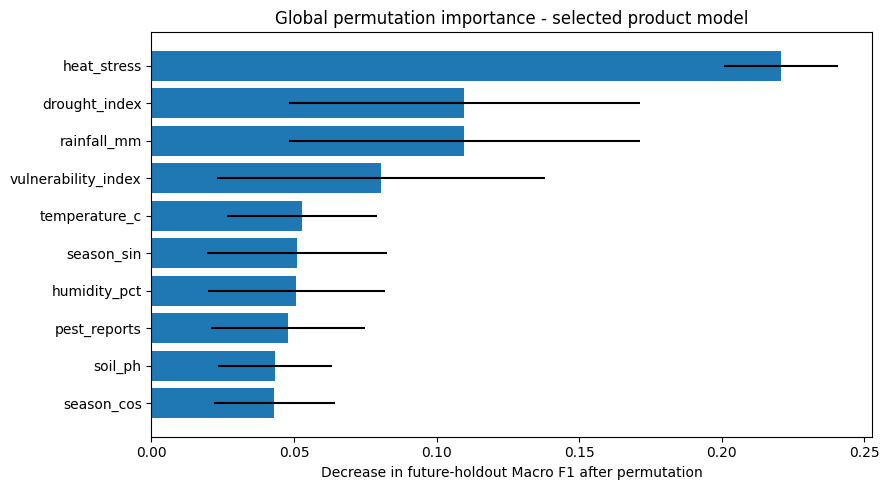

In [7]:
# Select the strongest ten features and reverse the order for plotting.
top_importance = permutation_table.head(10).sort_values("importance_mean")

# Create a dedicated chart.
plt.figure(figsize=(9, 5))

# Plot mean importance with repeated-shuffle standard deviations.
plt.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
)

# Label the axis with the actual scoring contract.
plt.xlabel("Decrease in future-holdout Macro F1 after permutation")

# Add a precise chart title.
plt.title("Global permutation importance - selected product model")

# Prevent clipping.
plt.tight_layout()

# Display the chart.
plt.show()


### How to explain this output
The bar length is the average Macro F1 decrease after repeated shuffles. The error bar shows repeat-to-repeat variation. Strong bars with small uncertainty are easier to trust.

## 7. Local occlusion explanation

$$
\Delta_{j,c}(x)=p_c(x)-p_c\left(x_{j\leftarrow r_j}\right)
$$

A positive effect means the original feature value increased support for class $c$ relative to the reference. A negative effect means it reduced support.


In [8]:
# Define a model-agnostic local probability-sensitivity function.
def local_occlusion_table(model, sample, reference, features, class_id):
    # Calculate the original selected-class probability.
    base_probability = model.predict_proba(sample[features])[0, class_id]

    # Create a collection for feature-level effects.
    records = []

    # Replace one feature at a time.
    for feature in features:
        # Copy the case so the original row remains unchanged.
        altered = sample.copy()

        # Replace the selected feature with its reference value.
        altered.loc[:, feature] = reference[feature]

        # Recalculate the selected-class probability.
        changed_probability = model.predict_proba(altered[features])[0, class_id]

        # Measure the support contributed by the original feature value.
        effect = base_probability - changed_probability

        # Store one interpretable record.
        records.append(
            {
                "feature": feature,
                "case_value": float(sample.iloc[0][feature]),
                "reference_value": float(reference[feature]),
                "base_probability": float(base_probability),
                "changed_probability": float(changed_probability),
                "local_effect": float(effect),
                "absolute_effect": float(abs(effect)),
            }
        )

    # Rank factors by local effect magnitude.
    return pd.DataFrame(records).sort_values(
        "absolute_effect",
        ascending=False,
    ).reset_index(drop=True)

# Use development medians as the primary reference profile.
reference_medians = train[selected_features].median()

# Confirm that the explainer is ready.
print("Local occlusion function ready.")


Local occlusion function ready.


### How to explain this output
This function creates a local sensitivity explanation. It asks: if only this feature were replaced by a typical training value, how much would the selected-class probability change?

## 8. Build one representative local case for every predicted class


In [9]:
# Create a collection for casebook summaries.
casebook_summaries = []

# Inspect one available prediction from every output class.
for class_id, class_name in enumerate(CLASS_NAMES):
    # Find positions predicted as the current class.
    positions = np.flatnonzero(y_pred == class_id)

    # Skip unavailable predicted classes.
    if len(positions) == 0:
        continue

    # Select the first available case.
    case_position = int(positions[0])

    # Extract the single-row case.
    sample = test.iloc[[case_position]].copy()

    # Build a class-aligned local explanation.
    local_table = local_occlusion_table(
        selected_model,
        sample,
        reference_medians,
        selected_features,
        class_id,
    )

    # Export the detailed local explanation.
    local_table.to_csv(
        REPORTS_DIR / f"session3_local_case_{class_name}.csv",
        index=False,
    )

    # Store a compact casebook record.
    casebook_summaries.append(
        {
            "case_position": case_position,
            "region_id": sample.iloc[0]["region_id"],
            "year": int(sample.iloc[0]["year"]),
            "month": int(sample.iloc[0]["month"]),
            "actual_class": sample.iloc[0]["risk_label"],
            "predicted_class": class_name,
            "raw_confidence": float(holdout_probabilities[case_position, class_id]),
            "top_positive_factor": local_table.sort_values("local_effect", ascending=False).iloc[0]["feature"],
            "top_negative_factor": local_table.sort_values("local_effect", ascending=True).iloc[0]["feature"],
        }
    )

# Convert records into the casebook table.
casebook = pd.DataFrame(casebook_summaries)

# Export the casebook summary.
casebook.to_csv(REPORTS_DIR / "session3_local_casebook_summary.csv", index=False)

# Display the casebook.
display(casebook)


,case_position,region_id,year,month,actual_class,predicted_class,raw_confidence,top_positive_factor,top_negative_factor
0,0,R01,2025,1,LOW,LOW,0.998709,rainfall_mm,humidity_pct
1,5,R01,2025,6,MEDIUM,MEDIUM,0.541684,rainfall_mm,vulnerability_index
2,30,R03,2025,7,MEDIUM,HIGH,0.504587,drought_index,heat_stress


### How to explain this output
Each row is a compact case explanation. It should be read as: actual class, predicted class, confidence, strongest supporting local factors, and strongest opposing factors.

## 9. Apply class-aware SHAP to the selected logistic model

$$
g_c(f(x))=\phi_{0,c}+\sum_{j=1}^{M}\phi_{j,c}
$$

The selected model is a pipeline. Its fitted preprocessing stage must transform both the background data and explained cases before `LinearExplainer` is applied to the fitted logistic classifier.


In [10]:
# Import SHAP for additive feature attribution.
import shap

# Extract the fitted preprocessing stage from the selected pipeline.
preprocessor = selected_model.named_steps["prepare"]

# Extract the fitted logistic classifier from the selected pipeline.
linear_model = selected_model.named_steps["model"]

# Transform development data with the fitted preprocessing contract.
X_background = preprocessor.transform(train[selected_features])

# Transform future-holdout data with the same fitted contract.
X_explain = preprocessor.transform(test[selected_features])

# Convert sparse matrices when required by the explainer.
if hasattr(X_background, "toarray"):
    X_background = X_background.toarray()

# Convert sparse holdout matrices when required.
if hasattr(X_explain, "toarray"):
    X_explain = X_explain.toarray()

# Retrieve readable transformed feature names.
transformed_feature_names = [
    name.split("__", 1)[-1]
    for name in preprocessor.get_feature_names_out()
]

# Create a compact representative background for live execution.
linear_explainer = shap.LinearExplainer(
    linear_model,
    X_background[:120],
)

# Explain all future-holdout cases in the classifier decision-score space.
linear_explanation = linear_explainer(X_explain)

# Display the multiclass tensor shape.
print("Linear SHAP shape:", np.asarray(linear_explanation.values).shape)


Linear SHAP shape: (120, 16, 3)


/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### How to explain this output
The selected logistic model is explained directly. The output shape tells whether SHAP returned one attribution vector or one vector per class. For multiclass models, the class axis must be handled carefully.

In [11]:
# Define a helper that extracts one case and one class from SHAP outputs.
def class_shap_table(explanation, case_index, class_id, feature_names, transformed_values):
    # Convert SHAP values to a NumPy array.
    values = np.asarray(explanation.values)

    # Handle multiclass output: cases x features x classes.
    if values.ndim == 3:
        # Select the class-specific feature vector.
        local_values = values[case_index, :, class_id]
    elif values.ndim == 2:
        # Use the direct feature vector for a single-output explainer.
        local_values = values[case_index, :]
    else:
        # Reject an unsupported output structure clearly.
        raise ValueError(f"Unsupported SHAP value shape: {values.shape}")

    # Build an interpretable attribution table.
    table = pd.DataFrame(
        {
            "feature": feature_names,
            "transformed_value": transformed_values[case_index],
            "shap_value": local_values,
            "absolute_shap": np.abs(local_values),
        }
    )

    # Rank by contribution magnitude.
    return table.sort_values("absolute_shap", ascending=False).reset_index(drop=True)

# Confirm that the extraction helper is ready.
print("Class-aware SHAP extraction ready.")


Class-aware SHAP extraction ready.


### How to explain this output
This helper extracts the correct class-specific SHAP vector. Positive values move the selected class score upward; negative values move it downward.

## 10. Find and autopsy one genuine wrong prediction


In [12]:
# Find all positions where predicted and actual classes differ.
wrong_positions = np.flatnonzero(y_pred != y_test)

# Stop clearly if the deterministic run unexpectedly has no error.
if len(wrong_positions) == 0:
    raise RuntimeError("No wrong prediction is available for error analysis.")

# Select the first genuine error as the debugging target.
error_position = int(wrong_positions[0])

# Extract the wrong case.
error_sample = test.iloc[[error_position]].copy()

# Store actual and predicted class IDs.
error_actual_class_id = int(y_test[error_position])
error_predicted_class_id = int(y_pred[error_position])

# Build the probability-sensitivity explanation for the predicted class.
error_occlusion = local_occlusion_table(
    selected_model,
    error_sample,
    reference_medians,
    selected_features,
    error_predicted_class_id,
)

# Build the class-aware SHAP explanation for the same predicted class.
error_shap = class_shap_table(
    linear_explanation,
    error_position,
    error_predicted_class_id,
    transformed_feature_names,
    X_explain,
)

# Create a compact wrong-case summary.
error_summary = pd.DataFrame(
    [
        {
            "case_position": error_position,
            "region_id": error_sample.iloc[0]["region_id"],
            "year": int(error_sample.iloc[0]["year"]),
            "month": int(error_sample.iloc[0]["month"]),
            "actual_class": CLASS_NAMES[error_actual_class_id],
            "predicted_class": CLASS_NAMES[error_predicted_class_id],
            "raw_confidence": float(holdout_probabilities[error_position, error_predicted_class_id]),
            "top_occlusion_factor": error_occlusion.iloc[0]["feature"],
            "top_shap_factor": error_shap.iloc[0]["feature"],
        }
    ]
)

# Export the error artifacts.
error_summary.to_csv(REPORTS_DIR / "session3_wrong_case_summary.csv", index=False)
error_occlusion.to_csv(REPORTS_DIR / "session3_wrong_case_local_occlusion.csv", index=False)
error_shap.to_csv(REPORTS_DIR / "session3_wrong_case_linear_shap.csv", index=False)

# Display the evidence.
display(error_summary)
display(error_occlusion.head(8))
display(error_shap.head(8))


,case_position,region_id,year,month,actual_class,predicted_class,raw_confidence,top_occlusion_factor,top_shap_factor
0,4,R01,2025,5,MEDIUM,LOW,0.623792,vulnerability_index,humidity_pct


,feature,case_value,reference_value,base_probability,changed_probability,local_effect,absolute_effect
0,vulnerability_index,0.352000,5.280000e-01,0.623792,0.361271,0.262522,0.262522
1,rainfall_mm,13.400000,3.515000e+01,0.623792,0.816354,-0.192562,0.192562
2,drought_index,0.883478,6.943478e-01,0.623792,0.816354,-0.192562,0.192562
3,humidity_pct,25.400000,4.970000e+01,0.623792,0.452357,0.171435,0.171435
4,heat_stress,0.000000,1.416667e-01,0.623792,0.479888,0.143905,0.143905
5,season_cos,-0.500000,-6.123234e-17,0.623792,0.709303,-0.085511,0.085511
6,disease_pressure,0.542609,4.473913e-01,0.623792,0.672866,-0.049073,0.049073
7,disease_cases,62.400000,5.145000e+01,0.623792,0.672866,-0.049073,0.049073


,feature,transformed_value,shap_value,absolute_shap
0,humidity_pct,-1.422291,0.957175,0.957175
1,rainfall_mm,-1.073103,-0.922055,0.922055
2,drought_index,1.073103,-0.922055,0.922055
3,vulnerability_index,-1.143458,0.401510,0.401510
4,season_cos,-0.707107,-0.346745,0.346745
5,season_sin,1.224745,0.318779,0.318779
6,heat_stress,-0.861337,0.203525,0.203525
7,water_balance,-0.726829,-0.171595,0.171595


### How to explain this output
This helper extracts the correct class-specific SHAP vector. Positive values move the selected class score upward; negative values move it downward.

## 11. Verify SHAP additivity

$$
g_c(f(x))=\phi_{0,c}+\sum_j\phi_{j,c}
$$

For the selected logistic model, `LinearExplainer` reconstructs the classifier decision score for the selected class.


In [13]:
# Convert base values and SHAP values to arrays.
base_values = np.asarray(linear_explanation.base_values)
shap_values = np.asarray(linear_explanation.values)

# Extract the selected-class base value for the wrong case.
if base_values.ndim == 2:
    selected_base = float(base_values[error_position, error_predicted_class_id])
else:
    selected_base = float(base_values[error_predicted_class_id])

# Extract the selected-class feature contributions.
selected_contributions = shap_values[
    error_position,
    :,
    error_predicted_class_id,
]

# Reconstruct the selected-class decision score.
reconstructed_score = selected_base + float(selected_contributions.sum())

# Calculate the classifier's direct decision score.
direct_score = float(
    linear_model.decision_function(X_explain[[error_position]])[
        0,
        error_predicted_class_id,
    ]
)

# Calculate the numerical additivity residual.
additivity_residual = abs(reconstructed_score - direct_score)

# Display and verify the consistency evidence.
print(f"SHAP baseline: {selected_base:.9f}")
print(f"Sum of SHAP values: {selected_contributions.sum():.9f}")
print(f"Reconstructed score: {reconstructed_score:.9f}")
print(f"Direct decision score: {direct_score:.9f}")
print(f"Additivity residual: {additivity_residual:.3e}")

# Require close numerical agreement.
assert additivity_residual < 1e-8


SHAP baseline: 3.240791621
Sum of SHAP values: -0.347851247
Reconstructed score: 2.892940373
Direct decision score: 2.892940373
Additivity residual: 4.441e-16


### How to explain this output
This verifies the SHAP additivity rule: baseline plus all feature contributions reconstructs the model score. A very small residual supports that the explanation is internally consistent.

## 12. Measure explanation stability

$$
J(A,B)=\frac{|A\cap B|}{|A\cup B|}
$$

Two reasonable SHAP backgrounds are used. The top-five sets are compared with Jaccard similarity.


In [14]:
# Create two distinct but reasonable development backgrounds.
background_a = X_background[:120]
background_b = X_background[-120:]

# Fit one explainer for each background.
explainer_a = shap.LinearExplainer(linear_model, background_a)
explainer_b = shap.LinearExplainer(linear_model, background_b)

# Explain only the selected wrong case under both backgrounds.
explanation_a = explainer_a(X_explain[[error_position]])
explanation_b = explainer_b(X_explain[[error_position]])

# Build class-aware tables for both explanations.
table_a = class_shap_table(
    explanation_a,
    0,
    error_predicted_class_id,
    transformed_feature_names,
    X_explain[[error_position]],
)
table_b = class_shap_table(
    explanation_b,
    0,
    error_predicted_class_id,
    transformed_feature_names,
    X_explain[[error_position]],
)

# Convert the strongest five factors into sets.
top_a = set(table_a.head(5)["feature"])
top_b = set(table_b.head(5)["feature"])

# Calculate Jaccard similarity.
jaccard_similarity = len(top_a & top_b) / len(top_a | top_b)

# Display the stability evidence.
print("Background A top-5:", sorted(top_a))
print("Background B top-5:", sorted(top_b))
print(f"Jaccard similarity: {jaccard_similarity:.3f}")


Background A top-5: ['drought_index', 'humidity_pct', 'rainfall_mm', 'season_cos', 'vulnerability_index']
Background B top-5: ['drought_index', 'heat_stress', 'humidity_pct', 'rainfall_mm', 'vulnerability_index']
Jaccard similarity: 0.667


### How to explain this output
The selected logistic model is explained directly. The output shape tells whether SHAP returned one attribution vector or one vector per class. For multiclass models, the class axis must be handled carefully.

## 13. Convert explanation evidence into a falsifiable debugging hypothesis


In [15]:
# Extract the strongest SHAP driver for the wrong case.
strongest_shap_driver = error_shap.iloc[0]["feature"]

# Construct one evidence-linked and falsifiable debugging decision.
hypothesis = pd.DataFrame(
    [
        {
            "observed_failure": (
                f"{CLASS_NAMES[error_actual_class_id]} was predicted as "
                f"{CLASS_NAMES[error_predicted_class_id]}"
            ),
            "evidence": (
                f"The strongest class-aware SHAP driver was {strongest_shap_driver}; "
                "disease-related signals were duplicated across raw and engineered features."
            ),
            "hypothesis": (
                "The selected model may over-count correlated disease information near the "
                "MEDIUM/HIGH boundary."
            ),
            "next_test": (
                "Refit with one redundant disease representation removed or with stronger "
                "regularization while preserving the chronological split and metric contract."
            ),
            "success_condition": (
                "MEDIUM-to-HIGH false positives decrease without a material reduction in "
                "HIGH-class recall or future-holdout Macro F1."
            ),
        }
    ]
)

# Export the final debugging decision.
hypothesis.to_csv(REPORTS_DIR / "session3_debugging_hypothesis.csv", index=False)

# Display the final artifact.
display(hypothesis)


,observed_failure,evidence,hypothesis,next_test,success_condition
0,MEDIUM was predicted as LOW,The strongest class-aware SHAP driver was humi...,The selected model may over-count correlated d...,Refit with one redundant disease representatio...,MEDIUM-to-HIGH false positives decrease withou...


### How to explain this output
The final row converts explanation evidence into a scientific debugging decision: observed failure, supporting evidence, testable hypothesis, next experiment, and evaluation metric.

## 14. Optional: direct TreeExplainer on the corrected XGBoost candidate


In [16]:
# Keep the notebook usable when SHAP or the optional nonlinear backend differs by environment.
try:
    # Retrieve the corrected nonlinear pipeline and its feature contract.
    tree_pipeline, tree_features = models["advanced_correct"]

    # Retrieve the fitted preprocessing stage without assuming one package version.
    tree_preprocessor = (
        tree_pipeline.named_steps.get("prepare")
        or tree_pipeline.named_steps.get("preprocessor")
    )

    # Retrieve the fitted tree estimator without passing the surrounding pipeline to SHAP.
    direct_tree_model = (
        tree_pipeline.named_steps.get("model")
        or tree_pipeline.named_steps.get("classifier")
    )

    # Stop clearly if the expected pipeline stages are unavailable.
    if tree_preprocessor is None or direct_tree_model is None:
        raise KeyError("Could not resolve the nonlinear preprocessing and estimator stages.")

    # Transform the future-holdout sample with the fitted preprocessing contract.
    tree_sample = tree_preprocessor.transform(
        test[tree_features].iloc[:30]
    )

    # Convert sparse matrices when the selected transformer returns sparse output.
    if hasattr(tree_sample, "toarray"):
        tree_sample = tree_sample.toarray()

    # Create the optimized tree-specific explainer from the direct fitted estimator.
    tree_explainer = shap.TreeExplainer(direct_tree_model)

    # Calculate tree-specific SHAP values for a bounded live workload.
    tree_explanation = tree_explainer(tree_sample)

    # Report the returned multiclass attribution shape.
    print("Tree SHAP shape:", np.asarray(tree_explanation.values).shape)
except Exception as exc:
    # Explain clearly why the optional block was skipped in this environment.
    print(f"Optional Tree SHAP demonstration skipped: {exc}")


Tree SHAP shape: (30, 16, 3)


### How to explain this output
This optional block explains the corrected tree candidate with a tree-specific explainer. It is useful for comparison, but it does not replace the explanation of the selected product model.

## Session result

The selected legitimate model now has:

- a metric-aligned global reliance profile;
- representative local probability explanations;
- class-aware Linear SHAP attributions;
- one genuine wrong-case autopsy;
- an additivity verification;
- a background-stability measurement;
- one falsifiable next experiment.

**Next session:** probability calibration, anomaly detection, and ACCEPT / HUMAN REVIEW / REJECT routing.
